## COMPAS - 2 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import LogRegScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42
#seed = 13

In [5]:
data = pd.read_csv("dataset/compas_onerace.csv")
data = data.drop("Unnamed: 0", axis=1)

fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


In [6]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * MONISE
    * Random Weights

In [7]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

In [8]:
# Logistic Regression with equal weight to use as baseline model
equal = LogRegScalarization(num_objs=2,
                            X=X_train, 
                            y=y_train, 
                            fair_feat=fair_feature,
                            #tol=tol, max_iter=max_iter
                            )
equal.optimize(np.array([0.5, 0.5]))

### MOLA

21:38:33 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
21:38:33 | DEBUG | machinemoo | Finding 1th individual minimum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
21:38:33 | DEBUG | machinemoo | Finding 2th individual minimum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic

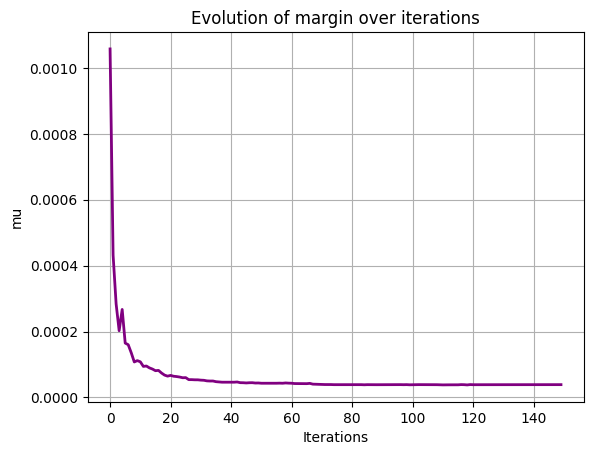

21:38:55 | INFO | machinemoo | Fit runtime: 21.78 seconds


In [9]:
method = 'mola'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

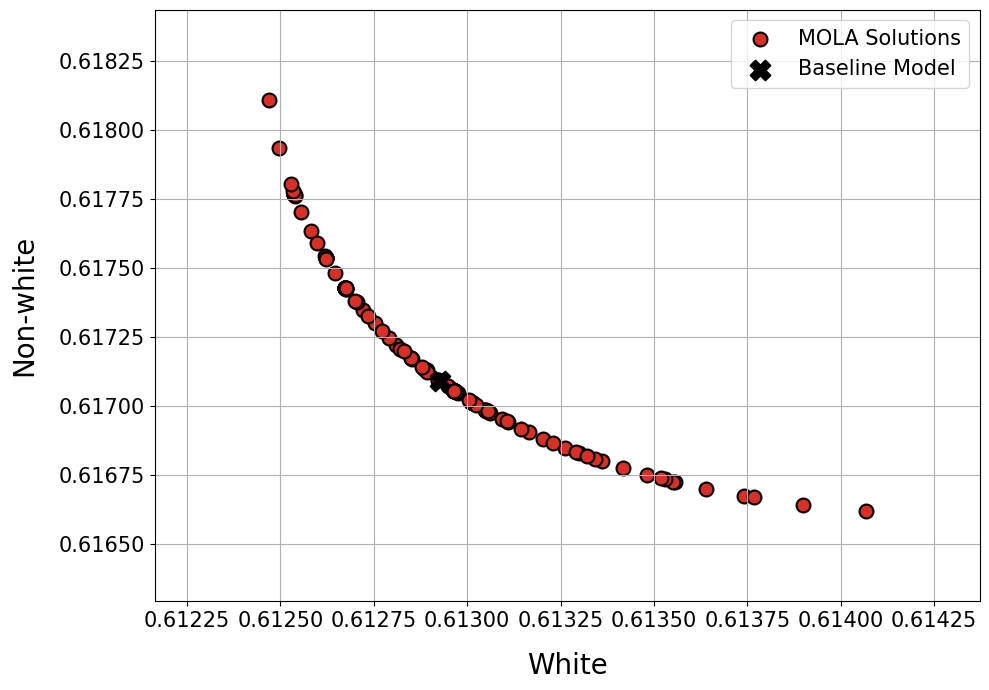

In [10]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            # color="#FF5C8D",
            fontsize=20,
            figsize=(10,7),
            save_path='images/2_objs_mola.pdf'
            )

In [11]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto_plotly(methods={'mola': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            color=['#FF5C8D', '#4BD6A0', '#9D5CFF'],
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_plotly.pdf'
            )

21:38:55 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
21:38:55 | DEBUG | machinemoo | Finding 1th individual minimum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:55 | DEBUG | machinemoo | Finding 2th individual minimum
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs

gradi  [[-0.07124063]
 [-0.00450192]
 [-0.00401619]
 [ 0.00862664]
 [ 0.00217202]
 [-0.00381989]
 [-0.00381989]]
gradi  [[ 0.00156326]
 [-0.00082794]
 [ 0.00074228]
 [ 0.00015303]
 [-0.00075292]
 [ 0.00080767]
 [ 0.00080767]]


21:38:55 | DEBUG | machinemoo | Calculated weights: [1. 0.]
21:38:55 | DEBUG | machinemoo | Importance: 0.010150453664262149
21:38:55 | DEBUG | machinemoo | Global lower bound (y*): [0.60245659 0.61662219]
21:38:55 | DEBUG | machinemoo | Iteration 1
21:38:55 | DEBUG | machinemoo | Solutions list: [array([0.61260705, 0.6189783 ]), array([0.61452791, 0.61662356])]
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:55 | DEBUG | machinemoo | New solution added [0.

gradi  [[-0.07261805]
 [-0.00374574]
 [-0.00289487]
 [ 0.00816179]
 [ 0.00127153]
 [-0.00778791]
 [-0.00778789]]


21:38:55 | DEBUG | machinemoo | Calculated weights: [1. 0.]
21:38:55 | DEBUG | machinemoo | Importance: 0.010546763058105757
21:38:55 | DEBUG | machinemoo | Global lower bound (y*): [0.60189735 0.61662219]
21:38:55 | DEBUG | machinemoo | Iteration 2
21:38:55 | DEBUG | machinemoo | Solutions list: [array([0.61244411, 0.61864463]), array([0.61452791, 0.61662356])]
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:55 | DEBUG | machinemoo | New solution added [0.

...

gradi  [[-0.07253639]
 [-0.00373219]
 [-0.00289894]
 [ 0.00816822]
 [ 0.00125555]
 [-0.00777557]
 [-0.00777556]]


21:38:56 | DEBUG | machinemoo | Calculated weights: [1. 0.]
21:38:56 | DEBUG | machinemoo | Importance: 0.01052305474737214
21:38:56 | DEBUG | machinemoo | Global lower bound (y*): [0.60192104 0.61662219]
21:38:56 | DEBUG | machinemoo | Iteration 14
21:38:56 | DEBUG | machinemoo | Solutions list: [array([0.6124441 , 0.61864331]), array([0.6124441, 0.6186433]), array([0.61452791, 0.61662356])]
21:38:56 | DEBUG | machinemoo | New solution added [0.6124441  0.61864331]
21:38:56 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [0.60192101 0.61662219]


gradi  [[-0.07253649]
 [-0.00373219]
 [-0.00289894]
 [ 0.00816822]
 [ 0.00125554]
 [-0.00777558]
 [-0.00777557]]


21:38:56 | DEBUG | machinemoo | Calculated weights: [1. 0.]
21:38:56 | DEBUG | machinemoo | Importance: 0.01052308501193322
21:38:56 | DEBUG | machinemoo | Global lower bound (y*): [0.60192101 0.61662219]
21:38:56 | DEBUG | machinemoo | Iteration 15
21:38:56 | DEBUG | machinemoo | Solutions list: [array([0.6124441 , 0.61864331]), array([0.6124441 , 0.61864331]), array([0.6124441, 0.6186433]), array([0.61452791, 0.61662356])]
21:38:56 | INFO | machinemoo | Best solution found.


gradi  [[-0.07253649]
 [-0.00373219]
 [-0.00289894]
 [ 0.00816822]
 [ 0.00125554]
 [-0.00777558]
 [-0.00777557]]


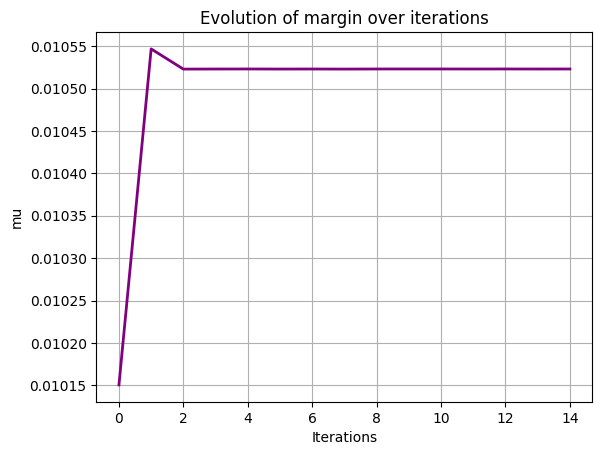

21:38:56 | INFO | machinemoo | Fit runtime: 0.44 seconds


In [ ]:
# Test with gradient
method = 'mola'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=True
                               )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f"{method}_grad"] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

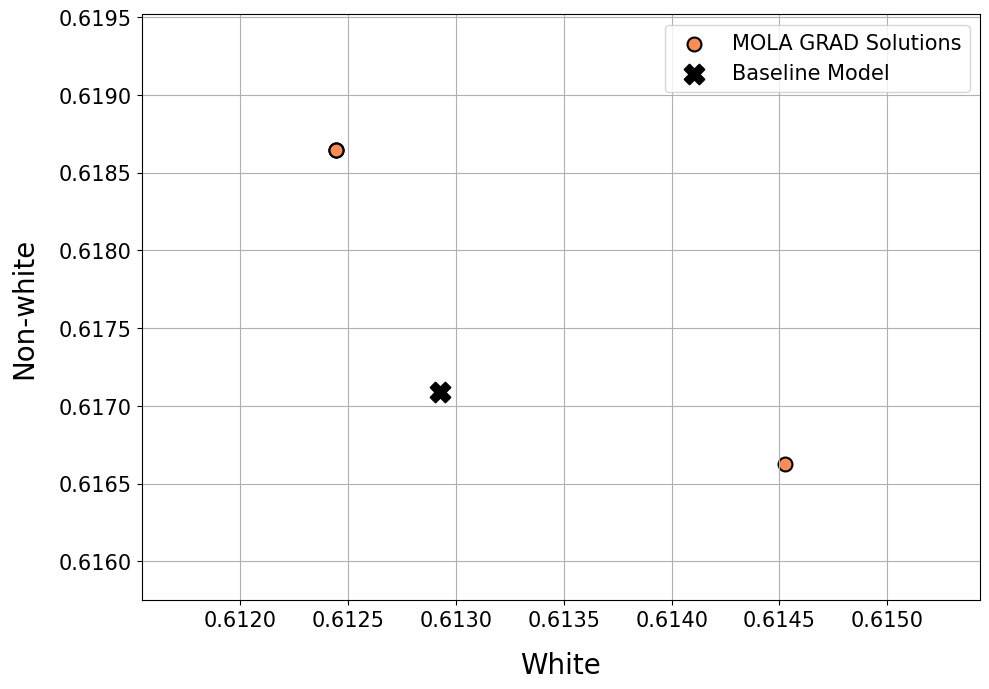

In [13]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'mola_grad': objs},
            color=['#fc8d59'],
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            fontsize=20,
            figsize=(10,7),
            save_path='images/2_objs_mola_grad.pdf'
            )

### NISE

In [15]:
method = 'nise'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

21:38:56 | WARNING | machinemoo | Ignored parameters for nise: {'nodeGap', 'nodeTimeLimit'}
21:38:56 | DEBUG | machinemoo | Filtered parameters for nise: {'targetSize': 150, 'targetGap': 0, 'norm': False}
21:38:56 | DEBUG | machinemoo | Finding 0th individual minima
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:56 | DEBUG | machinemoo | Finding 1th individual minima
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_mo

Finding 0th individual minima
Finding 1th individual minima
[array([0.61260705, 0.6189783 ]), array([0.61452791, 0.61662356])]
[array([0.61283158, 0.61719796]), array([0.61452791, 0.61662356])]
[array([0.61260705, 0.6189783 ]), array([0.61283158, 0.61719796])]
3th solution - importance: 0.06998962937882404
[array([0.61351914, 0.61673736]), array([0.61452791, 0.61662356])]
[array([0.61283158, 0.61719796]), array([0.61351914, 0.61673736])]
4th solution - importance: 0.016008781628043475
5th solution - importance: 0.006347188472137031
[array([0.6131226 , 0.61693171]), array([0.61351914, 0.61673736])]
[array([0.61283158, 0.61719796]), array([0.6131226 , 0.61693171])]
6th solution - importance: 0.002566639083675104
7th solution - importance: 0.0003907580725307831
[array([0.61297006, 0.61705386]), array([0.6131226 , 0.61693171])]
[array([0.61283158, 0.61719796]), array([0.61297006, 0.61705386])]
8th solution - importance: 0.0003868798211599307
[array([0.61330252, 0.61682575]), array([0.61351

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:56 | DEBUG | machinemoo | 26th solution - importance: 1.997853629466624e-07
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to s

[array([0.61317289, 0.61689798]), array([0.61320051, 0.61688115])]
[array([0.61314722, 0.61691395]), array([0.61317289, 0.61689798])]
26th solution - importance: 1.997853629466624e-07
[array([0.61338554, 0.61678699]), array([0.61342196, 0.61677163])]
[array([0.61335641, 0.61680006]), array([0.61338554, 0.61678699])]
27th solution - importance: 1.5039753804487738e-07
[array([0.61328522, 0.61683425]), array([0.61330252, 0.61682575])]
[array([0.61325304, 0.61685119]), array([0.61328522, 0.61683425])]
28th solution - importance: 1.1516224846236766e-07
[array([0.61322122, 0.61686885]), array([0.61325304, 0.61685119])]
[array([0.61320051, 0.61688115]), array([0.61322122, 0.61686885])]
29th solution - importance: 7.71966590582362e-08
[array([0.61332697, 0.61681361]), array([0.61335641, 0.61680006])]
[array([0.61330252, 0.61682575]), array([0.61332697, 0.61681361])]
30th solution - importance: 3.382188778829163e-08
[array([0.61307702, 0.61696238]), array([0.61308917, 0.61695344])]
[array([0.61

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:57 | DEBUG | machinemoo | 49th solution - importance: 2.165101039763603e-09
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to s

[array([0.61304669, 0.61698508]), array([0.613056  , 0.61697793])]
[array([0.61303747, 0.61699228]), array([0.61304669, 0.61698508])]
49th solution - importance: 2.165101039763603e-09
50th solution - importance: 2.032206225365486e-09
[array([0.6134946 , 0.61674436]), array([0.61350598, 0.61673982])]
[array([0.61348473, 0.61674745]), array([0.6134946 , 0.61674436])]
51th solution - importance: 1.7155217372437515e-09
[array([0.61340389, 0.61677917]), array([0.61340847, 0.6167772 ])]
[array([0.61338554, 0.61678699]), array([0.61340389, 0.61677917])]
52th solution - importance: 1.4549648998438726e-09
[array([0.61325992, 0.6168475 ]), array([0.61326864, 0.61684285])]
[array([0.61325304, 0.61685119]), array([0.61325992, 0.6168475 ])]
53th solution - importance: 1.3846292865113657e-09
[array([0.61322888, 0.61686451]), array([0.61323775, 0.61685955])]
[array([0.61322122, 0.61686885]), array([0.61322888, 0.61686451])]
54th solution - importance: 1.3559521680251524e-09
[array([0.61337845, 0.6167

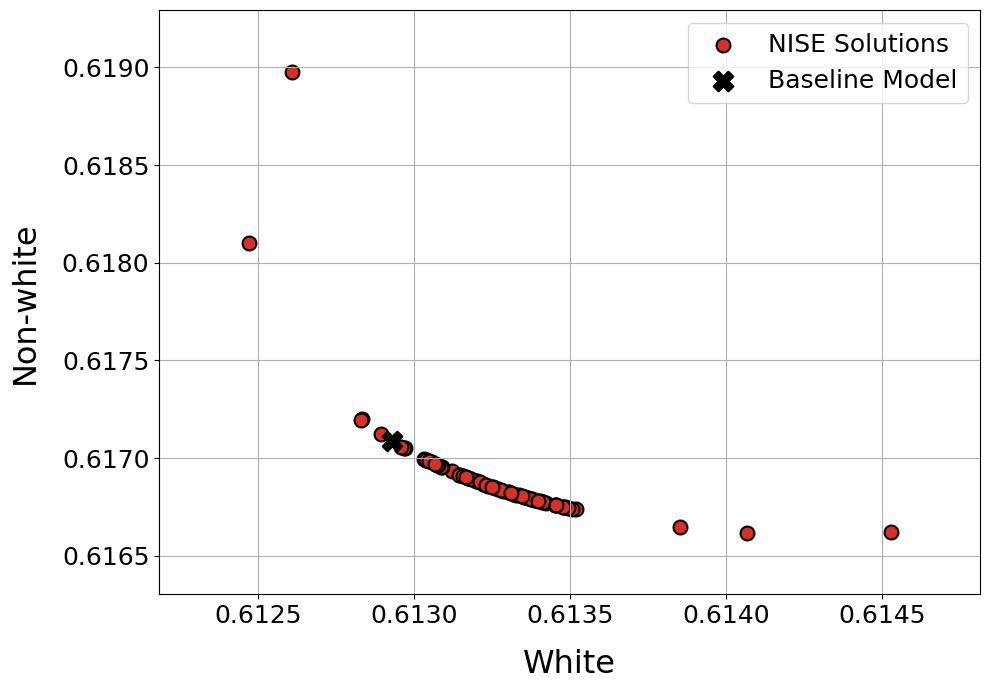

In [16]:
title="Loss Trade-offs for White and Non-White Person"
plot_pareto(methods={'nise': objs},
            labels=("White", "Non-White"), 
            title=title,
            point=equal.objs,
            #color="#FF5C8D",
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_nise.pdf'
            )

### MONISE

In [17]:
method = 'monise'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

21:38:57 | DEBUG | machinemoo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 150, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
21:38:57 | DEBUG | machinemoo | Finding 1th individual minima
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:57 | DEBUG | machinemoo | Finding 2th individual minima
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs fail

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:58 | DEBUG | machinemoo | 15th solution - importance: 0.02068270115325824
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to sca

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:38:58 | DEBUG | machinemoo | 23th solution - importance: 0.004786820892779991
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to sc

...

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:39:24 | DEBUG | machinemoo | 149th solution - importance: 0.0019203076303726718


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:39:24 | DEBUG | machinemoo | 150th solution - importance: 0.0019203076303726718


Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


### Ramdon Weighted Sum

In [18]:
method = 'random_weight'
w_scalar = LogRegScalarization(num_objs=2, 
                               X=X_train, 
                               y=y_train,
                               fair_feat=fair_feature,
                               tol=tol,
                               max_iter=max_iter, 
                               gradient=False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

21:39:25 | WARNING | machinemoo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
21:39:25 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}


21:39:25 | DEBUG | machinemoo | Finding 1th individual minima
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

21:39:25 | DEBUG | machinemoo | Finding 2th individual minima
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergen

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

### Color test

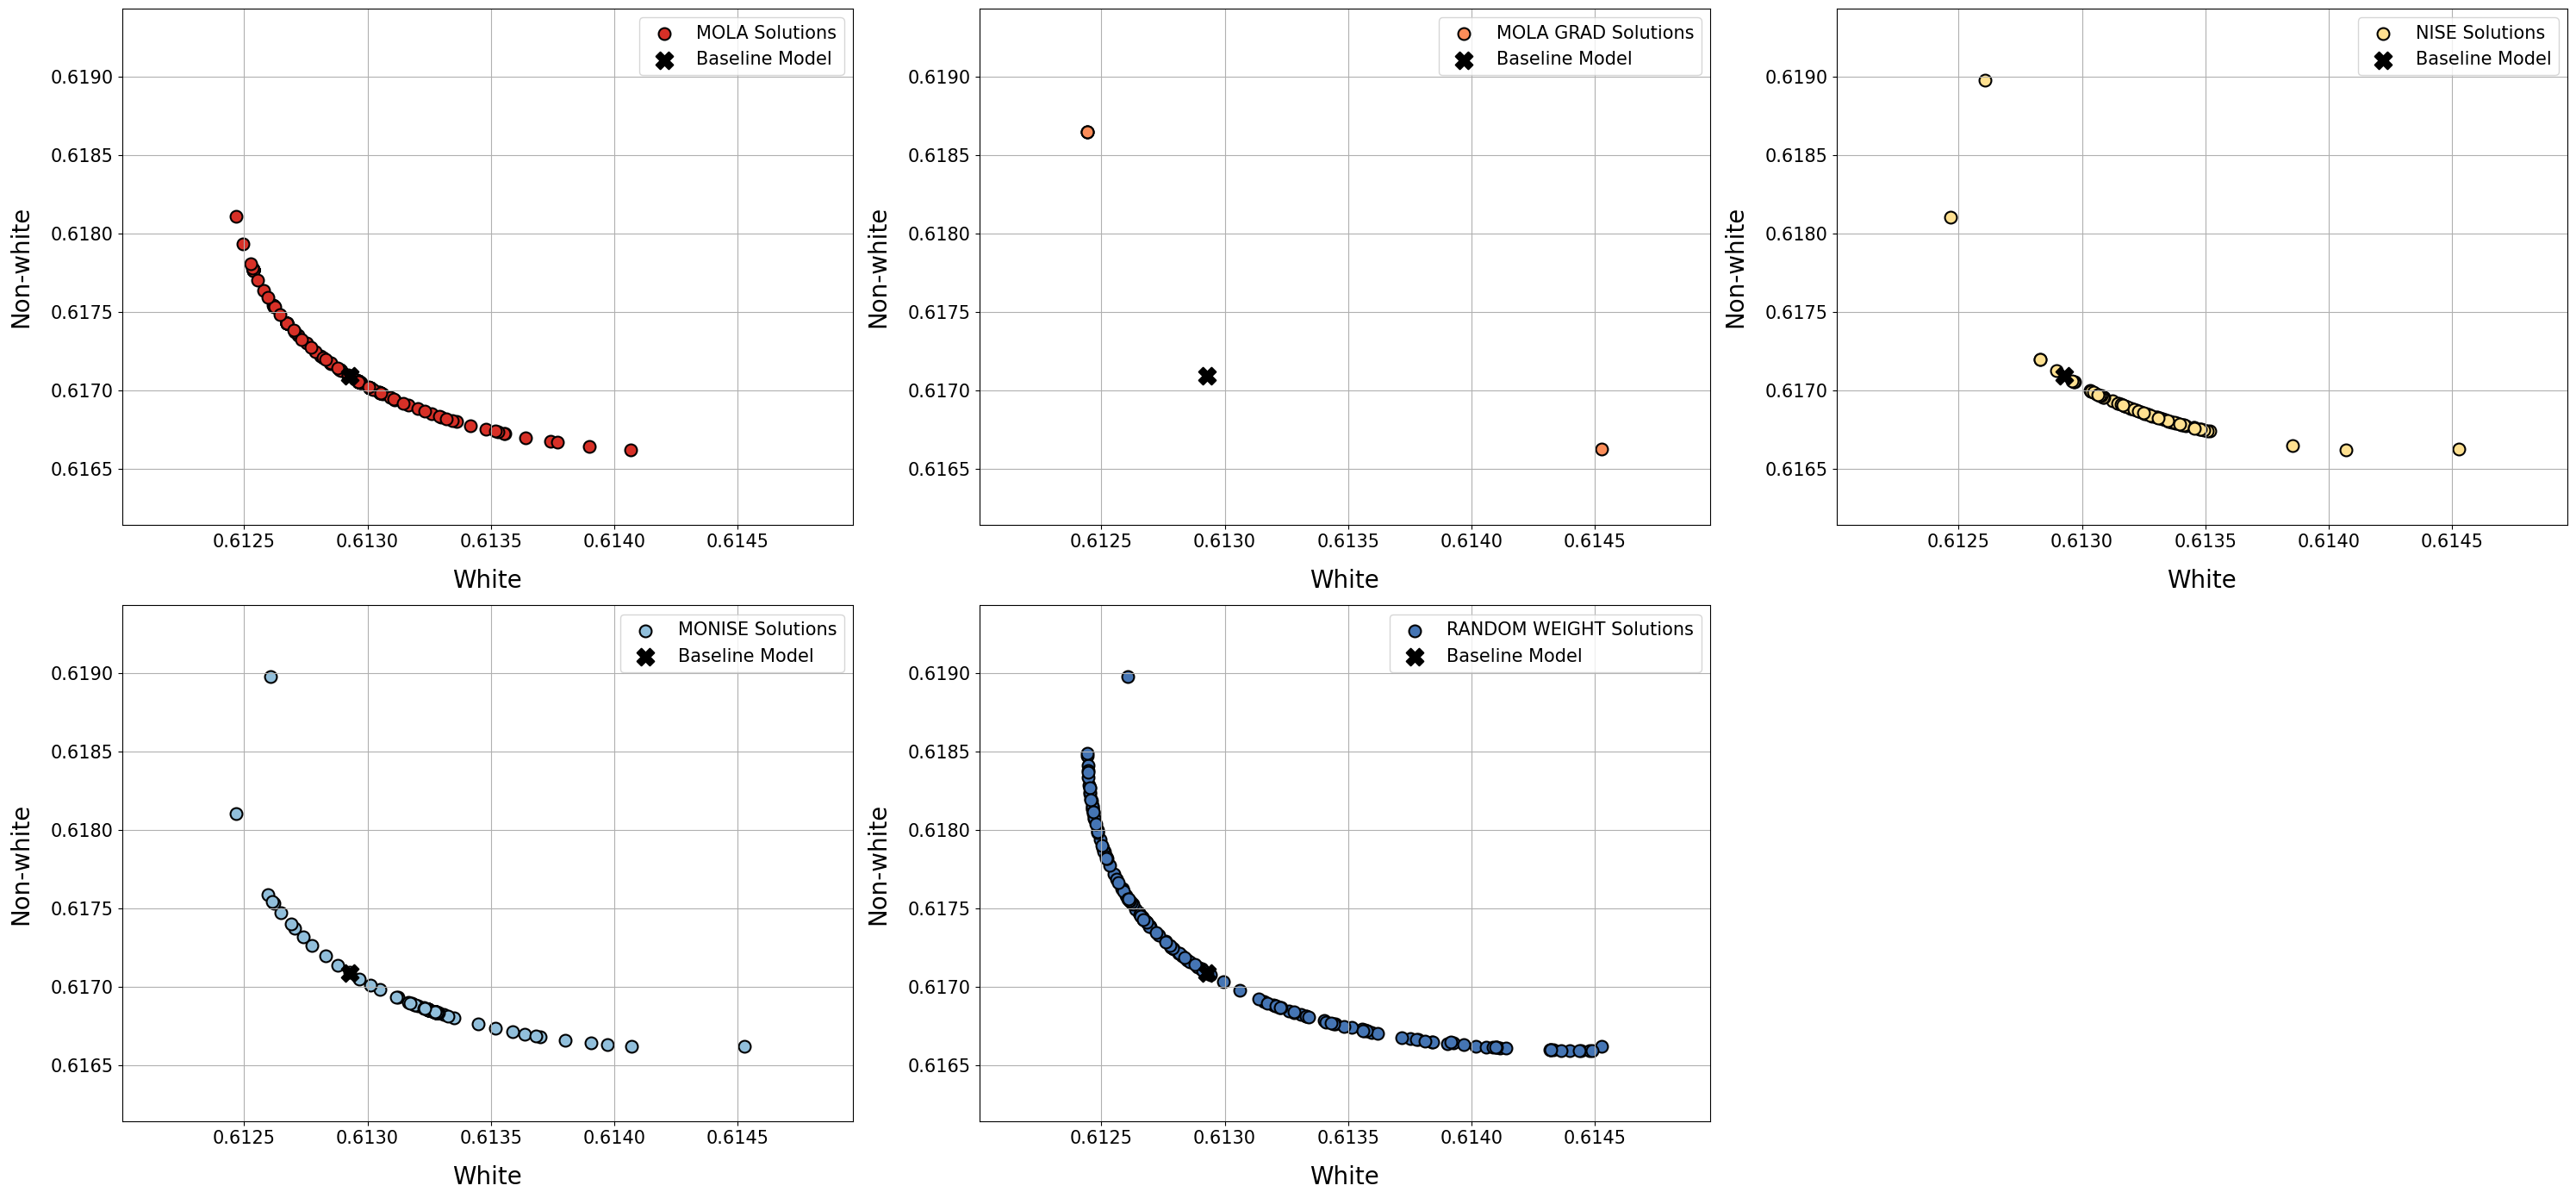

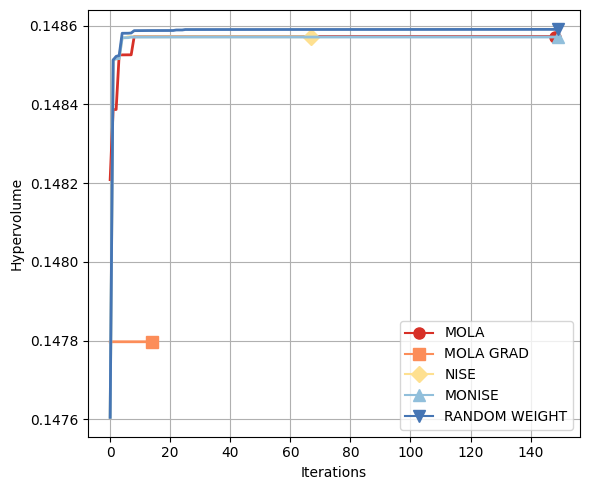

<Figure size 640x480 with 0 Axes>

In [19]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#FF5C8D', '#4BD6A0', '#9D5CFF']
axes_label = ["White", "Non-White"]
color = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
plot_pareto(methods=pareto_dict,
            labels=axes_label, 
            title=title,
            point=equal.objs,
            color=color,
            fontsize=20,
            figsize=(10,7),
            save_path='images/2_objs_methods.pdf'
            )

plot_pareto_plotly(methods=pareto_dict,
            labels=axes_label, 
            title=title,
            point=equal.objs,
            # color="#FF5C8D",
            fontsize=15,
            figsize=(10,7),
            save_path='images/2_objs_methods_plotly.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/2_objs_hypervolume.pdf", colors=color)

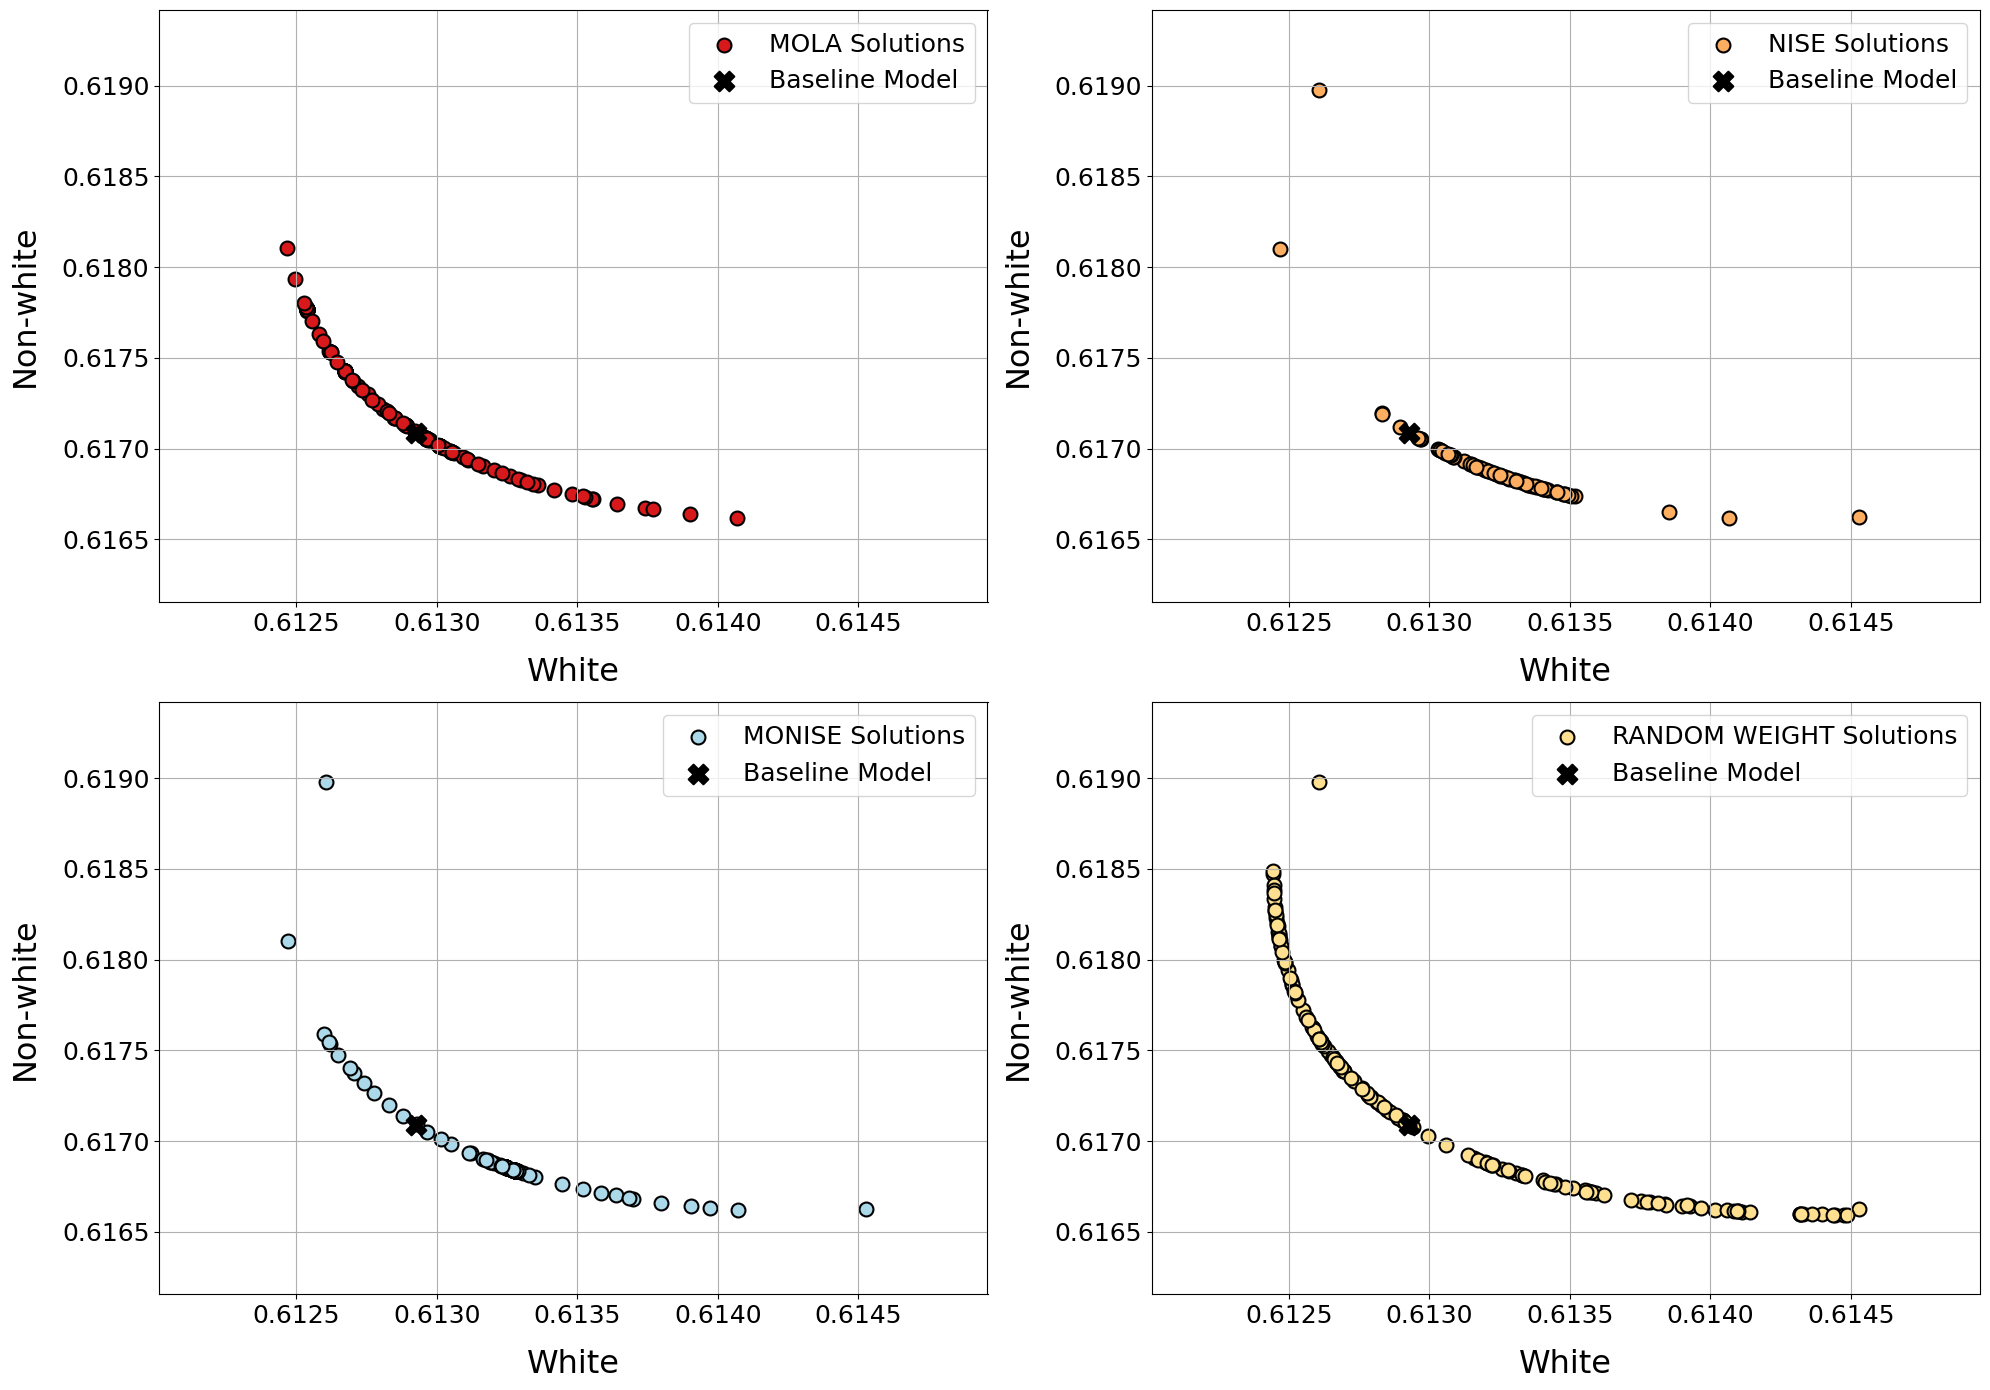

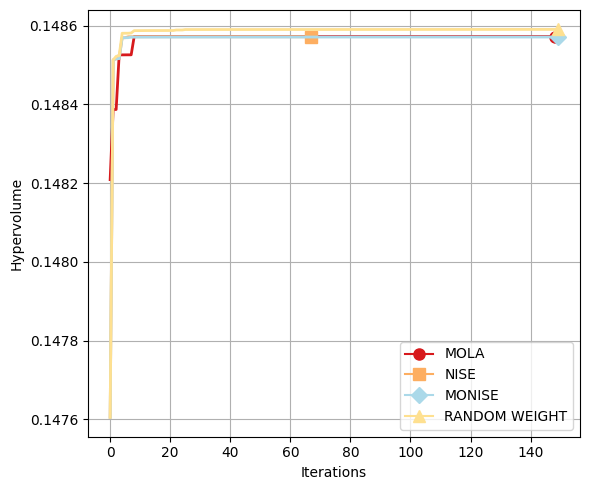

<Figure size 640x480 with 0 Axes>

In [20]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if ("objectives" in res) and (method != 'mola_grad')
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res and (method != 'mola_grad')
    }

#colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
#colors_hv = ['#FF5C8D', '#FF5C8D', '#4BD6A0', '#9D5CFF']
#olors_hv = ['#e66101', '#fdb863', '#b2abd2', '#5e3c99']
#colors_hv = ['#ca0020', '#f4a582', '#92c5de', '#0571b0']
colors = ['#d7191c', '#fdae61', '#abd9e9', '#fee090','#2c7bb6']

#['#d73027', '#fc8d59', '#4575b4', '#fee090', '#91bfdb', '#e0f3f8']

title = ""
axes_label = ["White", "Non-White"]

plot_pareto(methods=pareto_dict,
            labels=axes_label, 
            title=title,
            point=equal.objs,
            color=colors,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods.pdf'
            )

plot_pareto_plotly(methods=pareto_dict,
            labels=axes_label, 
            # title=title,
            point=equal.objs,
            color=colors_hv,
            fontsize=12,
            figsize=(10,7),
            save_path='images/2_objs_methods_plotly.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/2_objs_hypervolume.pdf", colors=colors)

### Ensemble

In [21]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

mola: 142
mola_grad: 4
Número de soluções não-dominadas (RW): 140
[[0.61344969 0.61676344]
 [0.61246034 0.61818787]
 [0.6139001  0.61663981]
 [0.61294057 0.61707878]
 [0.61244463 0.61847092]
 [0.6135555  0.61673233]
 [0.61265121 0.61747406]
 [0.61255006 0.61772171]
 [0.61258493 0.61762428]
 [0.61320471 0.61687901]
 [0.61269744 0.61738554]
 [0.61269456 0.61738907]
 [0.61284805 0.6171731 ]
 [0.61411351 0.61661154]
 [0.61249581 0.6179414 ]
 [0.61332874 0.61681457]
 [0.61375209 0.61666919]
 [0.61431838 0.61659756]
 [0.61275907 0.61729282]
 [0.61263898 0.61749464]
 [0.61444251 0.61659461]
 [0.61290688 0.61711497]
 [0.61359525 0.61671139]
 [0.61268004 0.61741807]
 [0.6137845  0.61666408]
 [0.6126268  0.61752549]
 [0.61315762 0.61690749]
 [0.61245254 0.61826865]
 [0.61330906 0.61682447]
 [0.61401612 0.61662243]
 [0.61245543 0.61823073]
 [0.61247232 0.61807342]
 [0.61351287 0.61674225]
 [0.61266663 0.61744413]
 [0.61250635 0.61788562]
 [0.61281314 0.61721547]
 [0.61285902 0.61716049]
 [0.61356

In [22]:
# Supondo que `solutions` seja seu array (N x M)
solutions = results['monise']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]

print(f"Número de soluções não-dominadas: {len(non_dominated_solutions)}")
print(non_dominated_solutions)

Número de soluções não-dominadas: 147
[[0.61283158 0.61719796]
 [0.61351914 0.61673736]
 [0.61246896 0.61810239]
 [0.6131226  0.61693171]
 [0.61259811 0.61758878]
 [0.61407061 0.61661992]
 [0.61379942 0.61665879]
 [0.61270496 0.61737415]
 [0.61330754 0.61682409]
 [0.61296702 0.6170522 ]
 [0.61264856 0.61747507]
 [0.61363657 0.61670055]
 [0.61344698 0.61676185]
 [0.61277542 0.61726549]
 [0.61320514 0.61687873]
 [0.61305078 0.61698199]
 [0.61287986 0.6171376 ]
 [0.61397137 0.61663046]
 [0.61274055 0.61732068]
 [0.61390553 0.61664122]
 [0.61269123 0.61740106]
 [0.6126199  0.61753588]
 [0.61335057 0.61680433]
 [0.61327498 0.61683962]
 [0.61261598 0.617546  ]
 [0.61370012 0.61668365]
 [0.61292825 0.61709179]
 [0.61358635 0.61671421]
 [0.61301359 0.61701292]
 [0.61311596 0.61693466]
 [0.61368263 0.6166864 ]
 [0.6131808  0.61689344]
 [0.61322686 0.61686569]
 [0.61328235 0.61683572]
 [0.61327967 0.61683709]
 [0.6132776  0.61683816]
 [0.61327986 0.61683699]
 [0.61328129 0.61683626]
 [0.61328013

In [23]:
# Supondo que `solutions` seja seu array (N x M)
solutions = results['nise']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]

print(f"Número de soluções não-dominadas: {len(non_dominated_solutions)}")
print(non_dominated_solutions)

Número de soluções não-dominadas: 64
[[0.61351914 0.61673736]
 [0.61246896 0.61810239]
 [0.6131226  0.61693171]
 [0.61406841 0.61661755]
 [0.61330252 0.61682575]
 [0.61342196 0.61677163]
 [0.61303271 0.61699645]
 [0.61289517 0.6171213 ]
 [0.61320051 0.61688115]
 [0.61308917 0.61695344]
 [0.61335641 0.61680006]
 [0.61325304 0.61685119]
 [0.61350598 0.61673982]
 [0.61385257 0.61664822]
 [0.61347575 0.61675088]
 [0.61314722 0.61691395]
 [0.61308555 0.61695602]
 [0.613056   0.61697793]
 [0.61296735 0.61705138]
 [0.61314359 0.6169163 ]
 [0.6128311  0.61719347]
 [0.61317289 0.61689798]
 [0.61338554 0.61678699]
 [0.61328522 0.61683425]
 [0.61322122 0.61686885]
 [0.61332697 0.61681361]
 [0.61307702 0.61696238]
 [0.61345152 0.61676024]
 [0.61340847 0.6167772 ]
 [0.61330435 0.6168246 ]
 [0.61326864 0.61684285]
 [0.61323775 0.61685955]
 [0.61348473 0.61674745]
 [0.61335171 0.61680203]
 [0.61317161 0.61689842]
 [0.61315732 0.61690735]
 [0.61319742 0.6168827 ]
 [0.61318273 0.61689153]
 [0.61331597 

In [24]:
from sklearn.metrics import accuracy_score
from machinemoo import run_ensemble

In [25]:
lambd = math.exp(-100)
clf = LogisticRegression(solver = 'lbfgs',
                           class_weight = None,
                           penalty = 'l2',
                           max_iter = max_iter,
                           tol = tol, 
                           C = 1/lambd,
                           warm_start = True)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
#predprob = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, pred)

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



In [26]:
#Logistic Regression Single Objctive
print(f'Logistic Regression Accuracy: {accuracy:.4f}')

Logistic Regression Accuracy: 0.6721


In [27]:
ensembles = {}
for method in results.keys():
    ensembles[method] = {
        'acc_voting'   : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='voting'),
        'acc_baggin'   : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='baggin'),
        'acc_adaboost' : run_ensemble(optimizer=None, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, models=results[method]['models'], ensemble_type='adaboost')
    }

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning:

lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessi

In [28]:
for method, ensemble in ensembles.items():
    print(f'\nMethod {method.upper()}')
    print(f'  Voting Accuracy:   {ensemble["acc_voting"]:.4f}')
    print(f'  Bagging Accuracy:  {ensemble["acc_baggin"]:.4f}')
    print(f'  Adaboost Accuracy: {ensemble["acc_adaboost"]:.4f}')


Method MOLA
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6698
  Adaboost Accuracy: 0.6721

Method MOLA_GRAD
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6708
  Adaboost Accuracy: 0.6721

Method NISE
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6692
  Adaboost Accuracy: 0.6721

Method MONISE
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6711
  Adaboost Accuracy: 0.6721

Method RANDOM_WEIGHT
  Voting Accuracy:   0.6721
  Bagging Accuracy:  0.6740
  Adaboost Accuracy: 0.6721


In [30]:
equal_model = equal.x
predictions = equal_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"acc {accuracy}")

acc 0.6675307841866494
